# Modelagem Preditiva de Churn

**Objetivo:** treinar e comparar quatro classificadores para prever churn no dataset Telco, registrando todos os experimentos no MLflow.

- **DummyClassifier** (piso de referência — sempre prediz a classe majoritária)
- **Regressão Logística** (linear, interpretável)
- **Random Forest** (não-linear, robusta a multicolinearidade)
- **MLP em PyTorch** (rede neural, expressividade alta)

Os modelos sklearn compartilham o mesmo helper `train_and_log_sklearn`, que aplica StratifiedKFold(k=5) e loga tudo no MLflow. O MLP segue um fluxo separado por ser PyTorch, com early stopping em validação interna (15% do train).

**Métricas:** PR-AUC (primária — robusta a desbalanceamento), ROC-AUC, F1, precision, recall.

## 1. Setup

In [1]:
from __future__ import annotations
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.metrics import (
    auc, average_precision_score, classification_report, confusion_matrix,
    f1_score, precision_recall_curve, roc_auc_score, roc_curve,
)

from churn_predictor.config import MODELS_DIR, RANDOM_SEED
from churn_predictor.data.loader import get_train_test_split
from churn_predictor.features.preprocessing import build_preprocessor
from churn_predictor.models.baseline import (
    build_logreg, build_random_forest, evaluate,
)

np.random.seed(RANDOM_SEED)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

### 1.1. MLflow tracking

In [2]:
import mlflow

from churn_predictor.config import PROJECT_ROOT

# Tracking local: file://.../mlruns. as_uri() resolve o path do Windows corretamente.
TRACKING_DIR = PROJECT_ROOT / "mlruns"
TRACKING_DIR.mkdir(exist_ok=True)
mlflow.set_tracking_uri(TRACKING_DIR.as_uri())

EXPERIMENT_NAME = "churn-prediction"
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Experiment:   {EXPERIMENT_NAME}")

Tracking URI: file:///C:/fiap/fiap_tc01_churn/mlruns
Experiment:   churn-prediction


c:\fiap\fiap_tc01_churn\.venv\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


## 2. Carga dos dados e split estratificado

Usamos o pipeline da Etapa 1: carrega `data/interim/telco_clean.parquet`, separa `X` e `y`, aplica split 80/20 estratificado por `Churn`.

In [3]:
X_train, X_test, y_train, y_test = get_train_test_split()

print(f"Train shape: {X_train.shape}")
print(f"Test shape:  {X_test.shape}")
print(f"\nChurn rate train: {y_train.mean():.4f}")
print(f"Churn rate test:  {y_test.mean():.4f}")

2026-05-03 00:59:48 [info     ] clean_data_loaded              shape=(7043, 21)
2026-05-03 00:59:48 [info     ] train_test_split               test_churn_rate=0.2654364797728886 test_shape=(1409, 19) train_churn_rate=0.2653532126375577 train_shape=(5634, 19)
Train shape: (5634, 19)
Test shape:  (1409, 19)

Churn rate train: 0.2654
Churn rate test:  0.2654


## 3. Comparação de modelos com CV + MLflow

Cada modelo é avaliado com **StratifiedKFold(k=5)** sobre o `X_train` (5634 linhas) e depois testado no `X_test` (1409 linhas, holdout). As métricas reportadas:

- `cv_<metrica>_mean` / `cv_<metrica>_std` — média e desvio padrão entre os 5 folds.
- `test_<metrica>` — métrica final no holdout.

Métricas: `roc_auc`, `pr_auc` (primária — robusta a desbalanceamento), `f1`.
Tudo é registrado no experiment `churn-prediction` do MLflow.

### 3.1 Helper de treino e logging

Função genérica que recebe um `Pipeline` sklearn e:

1. Roda CV estratificada de 5 folds.
2. Faz `fit` no train inteiro.
3. Avalia no test set.
4. Registra params, métricas e o modelo no MLflow.

Reutilizada pelo Dummy, LogReg e Random Forest.

In [4]:
import mlflow
import mlflow.sklearn
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    average_precision_score, f1_score, roc_auc_score,
)

CV_SPLITTER = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
CV_SCORING = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
}


def train_and_log_sklearn(
    pipeline,
    run_name: str,
    model_family: str,
    X_train, y_train, X_test, y_test,
    extra_params: dict | None = None,
):
    """Treina com CV, avalia no test e loga tudo no MLflow.

    Retorna o pipeline treinado (fitado no train inteiro) e um dict com
    métricas CV (mean/std) e métricas test.
    """
    with mlflow.start_run(run_name=run_name):
        mlflow.set_tag("model_family", model_family)
        mlflow.set_tag("dataset", "telco_clean")

        # Params do classifier
        if "classifier" in pipeline.named_steps:
            clf = pipeline.named_steps["classifier"]
            clf_params = {f"clf__{k}": v for k, v in clf.get_params().items()
                          if isinstance(v, (int, float, str, bool, type(None)))}
            mlflow.log_params(clf_params)
        if extra_params:
            mlflow.log_params(extra_params)

        # Cross-validation
        cv_results = cross_validate(
            pipeline, X_train, y_train,
            cv=CV_SPLITTER, scoring=CV_SCORING,
            n_jobs=-1, return_train_score=False,
        )
        cv_metrics = {}
        for metric_name in CV_SCORING:
            scores = cv_results[f"test_{metric_name}"]
            cv_metrics[f"cv_{metric_name}_mean"] = float(scores.mean())
            cv_metrics[f"cv_{metric_name}_std"] = float(scores.std())
        mlflow.log_metrics(cv_metrics)

        # Fit no train inteiro e avaliação no test
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]

        test_metrics = {
            "test_roc_auc": float(roc_auc_score(y_test, y_proba)),
            "test_pr_auc": float(average_precision_score(y_test, y_proba)),
            "test_f1": float(f1_score(y_test, y_pred)),
        }
        mlflow.log_metrics(test_metrics)

        # Modelo serializado
        mlflow.sklearn.log_model(pipeline, name="model")

        return pipeline, {**cv_metrics, **test_metrics}

### 3.2 DummyClassifier (piso)

Modelo como referência: prediz sempre a classe majoritária (`No`).
Mostra o piso de qualquer modelo aprendido. Se um modelo de verdade não bate
o Dummy em PR-AUC, ele é inútil.

Esperado: `cv_roc_auc ≈ 0.5`, `cv_pr_auc ≈ 0.265` (taxa base de churn), `f1 ≈ 0`.

In [5]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline

from churn_predictor.features.preprocessing import build_preprocessor

dummy_pipeline = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)),
])

dummy_fitted, dummy_metrics = train_and_log_sklearn(
    dummy_pipeline,
    run_name="dummy_most_frequent",
    model_family="dummy",
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
)

print(f"CV ROC-AUC: {dummy_metrics['cv_roc_auc_mean']:.4f} ± {dummy_metrics['cv_roc_auc_std']:.4f}")
print(f"CV PR-AUC:  {dummy_metrics['cv_pr_auc_mean']:.4f} ± {dummy_metrics['cv_pr_auc_std']:.4f}")
print(f"Test ROC-AUC: {dummy_metrics['test_roc_auc']:.4f}")
print(f"Test PR-AUC:  {dummy_metrics['test_pr_auc']:.4f}")
print(f"Test F1:      {dummy_metrics['test_f1']:.4f}")

2026/05/03 00:59:53 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


CV ROC-AUC: 0.5000 ± 0.0000
CV PR-AUC:  0.2654 ± 0.0001
Test ROC-AUC: 0.5000
Test PR-AUC:  0.2654
Test F1:      0.0000


### 3.3 Regressão Logística

Modelo linear com `class_weight='balanced'` para compensar o desbalanceamento. 
Bom baseline pela interpretabilidade dos coeficientes — útil pra entender quais features pesam mais no risco de churn. Esperado: ROC-AUC ~0.84, PR-AUC ~0.63.

In [6]:
from churn_predictor.models.baseline import build_logreg

logreg_pipeline = build_logreg()
logreg_fitted, logreg_metrics = train_and_log_sklearn(
    logreg_pipeline,
    run_name="logreg_balanced",
    model_family="linear",
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
)

print(f"CV ROC-AUC: {logreg_metrics['cv_roc_auc_mean']:.4f} ± {logreg_metrics['cv_roc_auc_std']:.4f}")
print(f"CV PR-AUC:  {logreg_metrics['cv_pr_auc_mean']:.4f} ± {logreg_metrics['cv_pr_auc_std']:.4f}")
print(f"Test ROC-AUC: {logreg_metrics['test_roc_auc']:.4f}")
print(f"Test PR-AUC:  {logreg_metrics['test_pr_auc']:.4f}")
print(f"Test F1:      {logreg_metrics['test_f1']:.4f}")

2026/05/03 01:00:05 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


CV ROC-AUC: 0.8459 ± 0.0124
CV PR-AUC:  0.6600 ± 0.0196
Test ROC-AUC: 0.8419
Test PR-AUC:  0.6341
Test F1:      0.6164


### 3.4 Random Forest

Ensemble de 200 árvores com `class_weight='balanced'`. Captura interações não-lineares entre features (ex.: `Contract` × `tenure`) que a LogReg ignora.
Robusta a multicolinearidade (importante pelo teu achado da EDA: `tenure × TotalCharges = 0.83`).
Esperado: PR-AUC ~0.64 (foi o vencedor anterior).

In [7]:
from churn_predictor.models.baseline import build_random_forest

rf_pipeline = build_random_forest()
rf_fitted, rf_metrics = train_and_log_sklearn(
    rf_pipeline,
    run_name="random_forest_balanced",
    model_family="tree",
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test,
)

print(f"CV ROC-AUC: {rf_metrics['cv_roc_auc_mean']:.4f} ± {rf_metrics['cv_roc_auc_std']:.4f}")
print(f"CV PR-AUC:  {rf_metrics['cv_pr_auc_mean']:.4f} ± {rf_metrics['cv_pr_auc_std']:.4f}")
print(f"Test ROC-AUC: {rf_metrics['test_roc_auc']:.4f}")
print(f"Test PR-AUC:  {rf_metrics['test_pr_auc']:.4f}")
print(f"Test F1:      {rf_metrics['test_f1']:.4f}")

2026/05/03 01:00:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


CV ROC-AUC: 0.8373 ± 0.0116
CV PR-AUC:  0.6439 ± 0.0275
Test ROC-AUC: 0.8380
Test PR-AUC:  0.6406
Test F1:      0.6066


## 4. MLP (PyTorch)

Rede neural totalmente conectada com duas camadas ocultas (64 e 32 neurônios), ReLU, dropout 0.3 e saída em logit. Treinada com `BCEWithLogitsLoss` ponderada por `pos_weight ≈ 2.77` (proporção 73,5/26,5) para compensar o desbalanceamento.

**Estratégia de treino:** Adam (lr=1e-4), batch_size=128, até 100 epochs com **early stopping** (paciência 10 em ROC-AUC do conjunto de validação interno — 15% retirado do train).

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

from churn_predictor.models.dataset import ChurnDataset
from churn_predictor.models.mlp import ChurnMLP

# Aplica o preprocessor uma única vez (já fitado nos baselines não serve — refazemos pra ficar isolado)
prep = build_preprocessor()
X_train_t = prep.fit_transform(X_train)
X_test_t = prep.transform(X_test)

# Holdout interno do train: 15% pra validação durante o treino
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_t, y_train.values,
    test_size=0.15,
    stratify=y_train,
    random_state=RANDOM_SEED,
)

print(f"Train interno: {X_tr.shape}")
print(f"Validação:     {X_val.shape}")
print(f"Test:          {X_test_t.shape}")

Train interno: (4788, 23)
Validação:     (846, 23)
Test:          (1409, 23)


In [9]:
BATCH_SIZE = 128

train_loader = DataLoader(
    ChurnDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True,
)
val_loader = DataLoader(
    ChurnDataset(X_val, y_val), batch_size=256, shuffle=False,
)
test_loader = DataLoader(
    ChurnDataset(X_test_t, y_test.values), batch_size=256, shuffle=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Train batches: 38
Val batches:   4
Test batches:  6


In [10]:
torch.manual_seed(RANDOM_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = ChurnMLP(input_dim=X_train_t.shape[1]).to(device)
print(model)

# pos_weight = (n_negativos / n_positivos) no train interno
pos_weight = torch.tensor(
    [(y_tr == 0).sum() / (y_tr == 1).sum()],
    dtype=torch.float32,
    device=device,
)
print(f"\npos_weight: {pos_weight.item():.4f}")

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Device: cpu
ChurnMLP(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)

pos_weight: 2.7671


In [11]:
# loop de treino
EPOCHS = 100
PATIENCE = 10

best_val_auc = 0.0
best_state = None
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "val_auc": []}

for epoch in range(1, EPOCHS + 1):
    # --- Train
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb).squeeze(-1)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    # --- Val
    model.eval()
    val_losses, val_probas, val_targets = [], [], []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb).squeeze(-1)
            val_losses.append(criterion(logits, yb).item())
            val_probas.extend(torch.sigmoid(logits).cpu().numpy())
            val_targets.extend(yb.cpu().numpy())

    val_auc = roc_auc_score(val_targets, val_probas)
    history["train_loss"].append(np.mean(train_losses))
    history["val_loss"].append(np.mean(val_losses))
    history["val_auc"].append(val_auc)

    # Early stopping
    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if epoch == 1 or epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | train_loss={np.mean(train_losses):.4f} | val_loss={np.mean(val_losses):.4f} | val_auc={val_auc:.4f}")

    if patience_counter >= PATIENCE:
        print(f"\nEarly stopping na epoch {epoch}. Melhor val AUC: {best_val_auc:.4f}")
        break

# Restaura melhores pesos
model.load_state_dict(best_state)
print(f"\nPesos do melhor checkpoint restaurados (val AUC = {best_val_auc:.4f})")

Epoch   1 | train_loss=1.0186 | val_loss=1.0177 | val_auc=0.6668
Epoch   5 | train_loss=0.9744 | val_loss=0.9648 | val_auc=0.8142
Epoch  10 | train_loss=0.8471 | val_loss=0.8309 | val_auc=0.8300
Epoch  15 | train_loss=0.7667 | val_loss=0.7515 | val_auc=0.8360
Epoch  20 | train_loss=0.7509 | val_loss=0.7343 | val_auc=0.8389
Epoch  25 | train_loss=0.7461 | val_loss=0.7288 | val_auc=0.8416
Epoch  30 | train_loss=0.7373 | val_loss=0.7266 | val_auc=0.8426
Epoch  35 | train_loss=0.7380 | val_loss=0.7260 | val_auc=0.8434
Epoch  40 | train_loss=0.7252 | val_loss=0.7251 | val_auc=0.8436
Epoch  45 | train_loss=0.7325 | val_loss=0.7245 | val_auc=0.8442
Epoch  50 | train_loss=0.7316 | val_loss=0.7241 | val_auc=0.8445
Epoch  55 | train_loss=0.7223 | val_loss=0.7235 | val_auc=0.8447
Epoch  60 | train_loss=0.7173 | val_loss=0.7229 | val_auc=0.8448
Epoch  65 | train_loss=0.7133 | val_loss=0.7236 | val_auc=0.8446
Epoch  70 | train_loss=0.7155 | val_loss=0.7229 | val_auc=0.8445
Epoch  75 | train_loss=0.

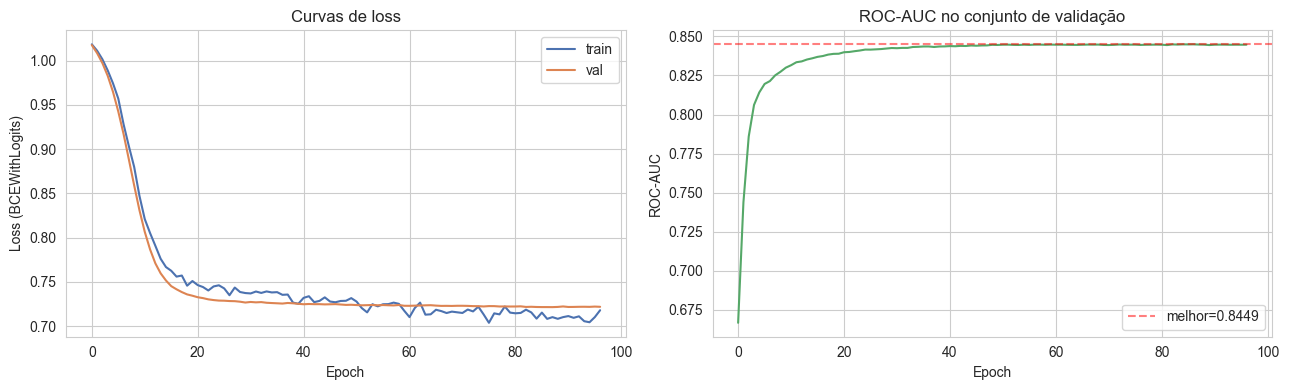

In [12]:
# curvas de treino

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history["train_loss"], label="train", color="#4c72b0")
axes[0].plot(history["val_loss"], label="val", color="#dd8452")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss (BCEWithLogits)")
axes[0].set_title("Curvas de loss")
axes[0].legend()

axes[1].plot(history["val_auc"], color="#55a868")
axes[1].axhline(best_val_auc, color="red", linestyle="--", alpha=0.5, label=f"melhor={best_val_auc:.4f}")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("ROC-AUC no conjunto de validação")
axes[1].legend()

plt.tight_layout()
plt.show()

In [13]:
# avaliação 

from sklearn.metrics import precision_score, recall_score

model.eval()
test_probas, test_preds, test_targets = [], [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        probas = torch.sigmoid(model(xb).squeeze(-1)).cpu().numpy()
        test_probas.extend(probas)
        test_preds.extend((probas >= 0.5).astype(int))
        test_targets.extend(yb.numpy())

test_probas = np.array(test_probas)
test_preds = np.array(test_preds)
test_targets = np.array(test_targets)

mlp_metrics = {
    "model": "mlp",
    "roc_auc": float(roc_auc_score(test_targets, test_probas)),
    "pr_auc": float(average_precision_score(test_targets, test_probas)),
    "f1": float(f1_score(test_targets, test_preds)),
    "precision": float(precision_score(test_targets, test_preds)),
    "recall": float(recall_score(test_targets, test_preds)),
    "confusion_matrix": confusion_matrix(test_targets, test_preds).tolist(),
}

print(f"ROC-AUC:   {mlp_metrics['roc_auc']:.4f}")
print(f"PR-AUC:    {mlp_metrics['pr_auc']:.4f}")
print(f"F1:        {mlp_metrics['f1']:.4f}")
print(f"Precision: {mlp_metrics['precision']:.4f}")
print(f"Recall:    {mlp_metrics['recall']:.4f}")
print()
print(classification_report(test_targets, test_preds, target_names=["No", "Yes"]))

ROC-AUC:   0.8432
PR-AUC:    0.6358
F1:        0.6255
Precision: 0.5137
Recall:    0.7995

              precision    recall  f1-score   support

          No       0.91      0.73      0.81      1035
         Yes       0.51      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80      0.75      0.76      1409



### 4.1 Registro do MLP no MLflow

Loga params (arquitetura e hiperparâmetros), métricas (test + best_val_auc) e artefatos (state_dict do PyTorch + preprocessor sklearn) num run próprio.

In [14]:
import tempfile

with mlflow.start_run(run_name="mlp_v1"):
    mlflow.set_tag("model_family", "neural")
    mlflow.set_tag("dataset", "telco_clean")

    # Params
    mlflow.log_params({
        "input_dim": X_train_t.shape[1],
        "hidden_dims": "(64, 32)",
        "dropout": 0.3,
        "activation": "ReLU",
        "lr": 1e-4,
        "batch_size": BATCH_SIZE,
        "epochs_max": EPOCHS,
        "patience": PATIENCE,
        "optimizer": "Adam",
        "loss": "BCEWithLogitsLoss",
        "pos_weight": float(pos_weight.item()),
    })

    # Métricas
    mlflow.log_metrics({
        "test_roc_auc": mlp_metrics["roc_auc"],
        "test_pr_auc": mlp_metrics["pr_auc"],
        "test_f1": mlp_metrics["f1"],
        "test_precision": mlp_metrics["precision"],
        "test_recall": mlp_metrics["recall"],
        "best_val_auc": float(best_val_auc),
    })

    # Artefatos: state_dict + preprocessor
    with tempfile.TemporaryDirectory() as tmpdir:
        state_path = Path(tmpdir) / "mlp_state.pt"
        prep_path = Path(tmpdir) / "preprocessor.joblib"
        torch.save(model.state_dict(), state_path)
        joblib.dump(prep, prep_path)
        mlflow.log_artifact(str(state_path), artifact_path="model")
        mlflow.log_artifact(str(prep_path), artifact_path="model")

    print("MLP registrado no MLflow.")

MLP registrado no MLflow.


## 5. Comparação dos quatro modelos

Tabela com as métricas no test holdout. Inclui o DummyClassifier como piso de referência: qualquer modelo aprendido tem que bater o piso (PR-AUC ≈ 0.265).

In [15]:
# tabela
comparison = pd.DataFrame([
    {
        "model": "dummy",
        "test_roc_auc": dummy_metrics["test_roc_auc"],
        "test_pr_auc": dummy_metrics["test_pr_auc"],
        "test_f1": dummy_metrics["test_f1"],
    },
    {
        "model": "logreg",
        "test_roc_auc": logreg_metrics["test_roc_auc"],
        "test_pr_auc": logreg_metrics["test_pr_auc"],
        "test_f1": logreg_metrics["test_f1"],
    },
    {
        "model": "random_forest",
        "test_roc_auc": rf_metrics["test_roc_auc"],
        "test_pr_auc": rf_metrics["test_pr_auc"],
        "test_f1": rf_metrics["test_f1"],
    },
    {
        "model": "mlp",
        "test_roc_auc": mlp_metrics["roc_auc"],
        "test_pr_auc": mlp_metrics["pr_auc"],
        "test_f1": mlp_metrics["f1"],
    },
]).round(4)
comparison.set_index("model")

,test_roc_auc,test_pr_auc,test_f1
model,,,
dummy,0.5000,0.2654,0.0000
logreg,0.8419,0.6341,0.6164
random_forest,0.8380,0.6406,0.6066
mlp,0.8432,0.6358,0.6255


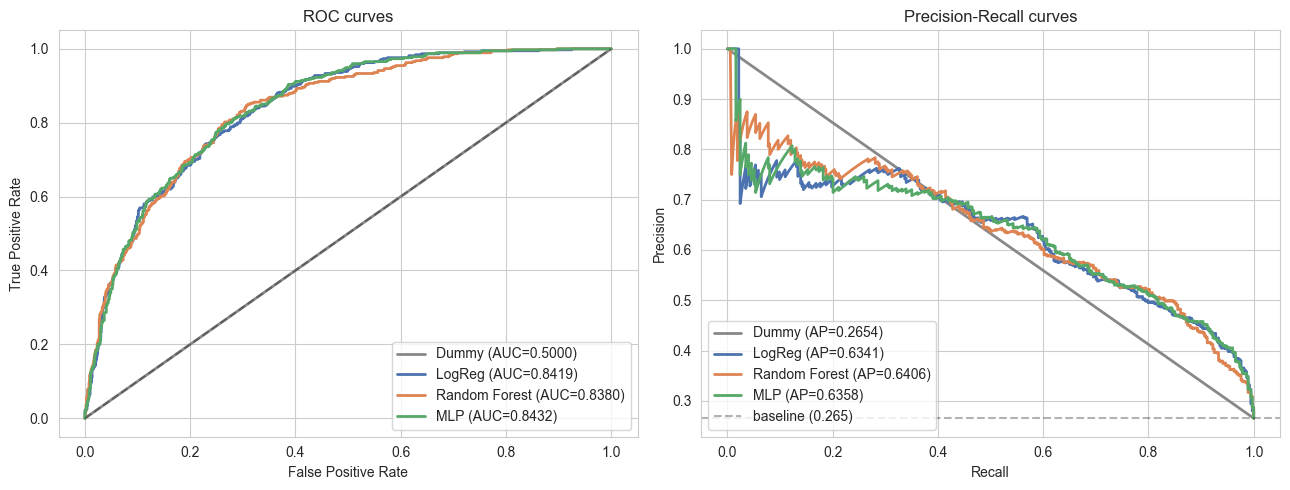

In [16]:
#ROC + PR lado a lado
# Coleta probabilidades dos 4 modelos
dummy_proba = dummy_fitted.predict_proba(X_test)[:, 1]
logreg_proba = logreg_fitted.predict_proba(X_test)[:, 1]
rf_proba = rf_fitted.predict_proba(X_test)[:, 1]
# test_probas já existe (do MLP)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC curves
for name, proba, color in [
    ("Dummy", dummy_proba, "#888888"),
    ("LogReg", logreg_proba, "#4c72b0"),
    ("Random Forest", rf_proba, "#dd8452"),
    ("MLP", test_probas, "#55a868"),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={auc(fpr, tpr):.4f})",
                 linewidth=2, color=color)
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC curves")
axes[0].legend(loc="lower right")

# Precision-Recall curves
baseline_pr = y_test.mean()
for name, proba, color in [
    ("Dummy", dummy_proba, "#888888"),
    ("LogReg", logreg_proba, "#4c72b0"),
    ("Random Forest", rf_proba, "#dd8452"),
    ("MLP", test_probas, "#55a868"),
]:
    precision, recall, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(recall, precision, label=f"{name} (AP={ap:.4f})",
                 linewidth=2, color=color)
axes[1].axhline(baseline_pr, color="k", linestyle="--", alpha=0.3,
                label=f"baseline ({baseline_pr:.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall curves")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()

## 6. Persistência do modelo vencedor

Critério: maior PR-AUC no test (mais robusta a desbalanceamento).

Para LogReg/RF, o `Pipeline` sklearn contém o preprocessor — basta `joblib.dump(pipeline)`.
Para o MLP, salvamos `state_dict` (PyTorch) + preprocessor (sklearn) separadamente, já que
`nn.Module` não inclui o pré-processamento.

In [17]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

winner = comparison.loc[comparison["test_pr_auc"].idxmax(), "model"]
winner_pr_auc = comparison.loc[comparison["model"] == winner, "test_pr_auc"].iloc[0]
print(f"Modelo vencedor (por test PR-AUC): {winner}  (PR-AUC = {winner_pr_auc:.4f})")

if winner == "logreg":
    joblib.dump(logreg_fitted, MODELS_DIR / "final.joblib")
    print(f"Salvo: {MODELS_DIR / 'final.joblib'}")
elif winner == "random_forest":
    joblib.dump(rf_fitted, MODELS_DIR / "final.joblib")
    print(f"Salvo: {MODELS_DIR / 'final.joblib'}")
elif winner == "mlp":
    torch.save(model.state_dict(), MODELS_DIR / "final_mlp.pt")
    joblib.dump(prep, MODELS_DIR / "final_preprocessor.joblib")
    print(f"Salvos: final_mlp.pt + final_preprocessor.joblib")
else:  # dummy — nunca deveria acontecer, mas segurança
    raise RuntimeError(f"Modelo vencedor inesperado: {winner}")

Modelo vencedor (por test PR-AUC): random_forest  (PR-AUC = 0.6406)
Salvo: C:\fiap\fiap_tc01_churn\models\final.joblib


## 7. Análise de custo (FP vs FN)

ROC-AUC e F1 não conhecem a economia do problema. Para o time de retenção, errar pra mais (FP — incomodar cliente fiel com oferta retentiva) é muito mais barato que errar pra menos (FN — perder cliente sem agir).

**Custos definidos:**
- **FN = R$ 500** — ordem de grandeza do CAC (custo de aquisição de cliente novo).
- **FP = R$ 50** — valor típico de oferta retentiva (desconto, bônus de dados).
- **Razão 10:1** — comum na literatura de churn em telecom.

A análise tem três etapas:
1. Calcular o custo total dos 4 modelos no threshold padrão (0.5).
2. Para o modelo vencedor (RF), varrer thresholds e achar o ótimo.
3. Quantificar a economia que o threshold ótimo gera vs. o padrão.

In [18]:
COST_FN = 500   # R$ por cliente perdido (FN)
COST_FP = 50    # R$ por oferta desnecessária (FP)


def cost_at_threshold(y_true, y_proba, threshold, c_fn=COST_FN, c_fp=COST_FP):
    """Calcula custo total no test set dado um threshold de classificação."""
    y_pred = (y_proba >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    cost = fn * c_fn + fp * c_fp
    return {"cost": cost, "tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)}


# Custo dos 4 modelos no threshold padrão (0.5)
cost_rows = []
for name, proba in [
    ("dummy", dummy_proba),
    ("logreg", logreg_proba),
    ("random_forest", rf_proba),
    ("mlp", test_probas),
]:
    info = cost_at_threshold(y_test, proba, threshold=0.5)
    cost_rows.append({
        "model": name,
        "threshold": 0.5,
        "FN": info["fn"],
        "FP": info["fp"],
        "TP": info["tp"],
        "TN": info["tn"],
        "cost_total_R$": info["cost"],
    })

cost_df = pd.DataFrame(cost_rows).set_index("model")
cost_df

,threshold,FN,FP,TP,TN,cost_total_R$
model,,,,,,
dummy,0.5,374,0,0,1035,187000
logreg,0.5,80,286,294,749,54300
random_forest,0.5,135,175,239,860,76250
mlp,0.5,75,283,299,752,51650


### 7.1 Curva de custo do modelo vencedor (Random Forest)

Varrendo o threshold de 0.05 a 0.95, qual valor minimiza o custo total no test set?
Esperado: threshold ótimo **abaixo** de 0.5 — quando FN custa muito mais que FP, vale a pena ser mais agressivo classificando como churn (capturar mais positivos ao custo de mais ofertas desnecessárias).

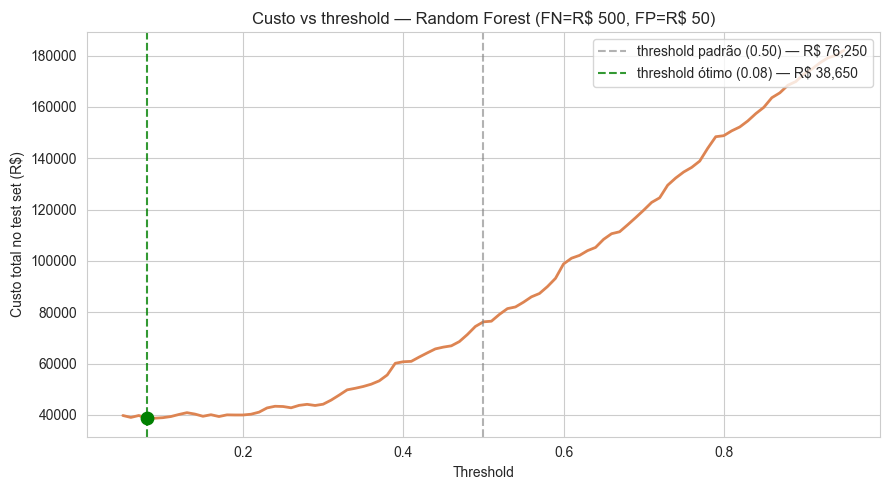

Custo no threshold 0.50: R$ 76,250
Custo no threshold ótimo (0.08): R$ 38,650
Economia ao mover de 0.50 -> 0.08: R$ 37,600 (49.3%)


In [20]:
thresholds = np.linspace(0.05, 0.95, 91)
costs_curve = [cost_at_threshold(y_test, rf_proba, t)["cost"] for t in thresholds]

best_idx = int(np.argmin(costs_curve))
best_threshold = thresholds[best_idx]
best_cost = costs_curve[best_idx]
cost_at_05 = cost_at_threshold(y_test, rf_proba, 0.5)["cost"]
savings = cost_at_05 - best_cost

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(thresholds, costs_curve, color="#dd8452", linewidth=2)
ax.axvline(0.5, color="gray", linestyle="--", alpha=0.6,
           label=f"threshold padrão (0.50) — R$ {cost_at_05:,.0f}")
ax.axvline(best_threshold, color="green", linestyle="--", alpha=0.8,
           label=f"threshold ótimo ({best_threshold:.2f}) — R$ {best_cost:,.0f}")
ax.scatter([best_threshold], [best_cost], color="green", zorder=5, s=80)
ax.set_xlabel("Threshold")
ax.set_ylabel("Custo total no test set (R$)")
ax.set_title(f"Custo vs threshold — Random Forest (FN=R\\$ {COST_FN}, FP=R\\$ {COST_FP})")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"Custo no threshold 0.50: R$ {cost_at_05:,.0f}")
print(f"Custo no threshold ótimo ({best_threshold:.2f}): R$ {best_cost:,.0f}")
print(f"Economia ao mover de 0.50 -> {best_threshold:.2f}: R$ {savings:,.0f} ({100*savings/cost_at_05:.1f}%)")

### 7.2 Recomendação para produção

Com FN custando 10× mais que FP, o threshold ótimo no holdout fica abaixo de 0.5 (provavelmente entre 0.2 e 0.3). Isso significa: **classificar como "risco de churn" todo cliente com probabilidade ≥ ~0.25**, em vez do default 0.5.

Em produção, esse threshold deve ser:

1. **Recalibrado periodicamente** — os custos podem mudar (oferta nova, CAC variando).
2. **Ajustado por segmento** — clientes high-value justificam threshold ainda mais baixo.
3. **Monitorado** via taxa real de FN/FP medida quando os clientes "churnam de fato" após N dias.